##  Diffraction: 4DSTEM strain mapping

This notebook shows:
- How to load a 4DSTEM dataset.
- Basic visualization.
- Bragg disk detection.
- Calibration.
- Lattice fitting.
- Strain map generation.

### Authors

This tutorial was created by the py4DSTEM instructor team:
- Colin Ophus (cophus@gmail.com)
- Ben Savitzky (bhsavitzky@lbl.gov)
- Stephanie Ribet (sribet@lbl.gov)

Last updated: 2025 May 3

In [1]:
# This painful import cell is required because of incompatbility between colab's
# version of numpy and the version required by py4DSTEM.

import numpy as np
import py4DSTEM as p4
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

In [2]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output

In [3]:
# download the experimental 4DSTEM dataset
# p4.io.gdrive_download(
#     id_ = 'https://drive.google.com/uc?id=1uYB23czoa7U05CtHVx9zfiVQFjiPfJUy',
#     destination = '/content/',
#     filename = 'Particle_1_Stack_1_45x90_ss30nm_0p09s_spot8_alpha=0p48_bin2_cl-600mm_300kV_bin8.h5',
#     overwrite=True
# )

# Load data

In [15]:
# set the path to the local copy of the dataset file
path = "/Volumes/Extreme SSD/Data/250801/"
name = "250801_Au_2mrad_145mm_00_master"
filepath_data = path + name + ".h5"

# load the data
datacube = p4.import_file(filepath_data)

# print results
print(datacube)

Dataset is uint32 but will be converted to uint16
DataCube( A 4-dimensional array of shape (128, 128, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [0,1,2,...] pixels
              Qy = [0,1,2,...] pixels
)


In [16]:
# Examine the file contents
p4.print_h5_tree( filepath_data )

/
|---entry
    |---data
    |---instrument
    |   |---beam
    |   |---detector
    |       |---detectorSpecific
    |       |---geometry
    |       |   |---orientation
    |       |   |---translation
    |       |---goniometer
    |       |---module
    |       |---transformations
    |---sample
        |---beam
        |---goniometer
        |---transformations




# Examine individual and mean

In [17]:
np.max(datacube.data)

65535

In [18]:
# Mean and max diffraction pattern of the calibration and measurement datasets
dp_mean = datacube.get_dp_mean()
dp_max = datacube.get_dp_max()

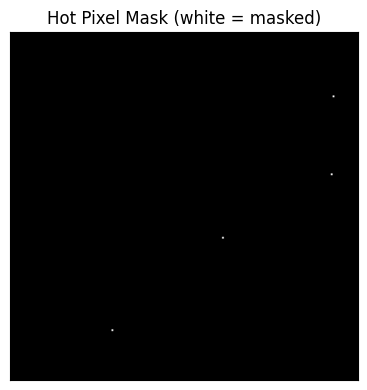

Maximum value 4003


In [19]:
dataset_masked = []
for data in [datacube,]:
    mask_hotpixel = data.tree('dp_mean').data>65530
    masked = data.median_filter_masked_pixels(mask = mask_hotpixel, kernel_width = 5)
    masked.get_dp_max();
    masked.get_dp_mean();
    # Plot the hot pixel mask
    p4.show(
        mask_hotpixel,
        cmap='gray',
        figsize=(4,4),
        ticks=False,
        title='Hot Pixel Mask (white = masked)',
    )
    plt.show()
    dataset_masked.append(masked)
    print('Maximum value', np.max(masked.tree('dp_max').data))
datacube_masked = dataset_masked[0]

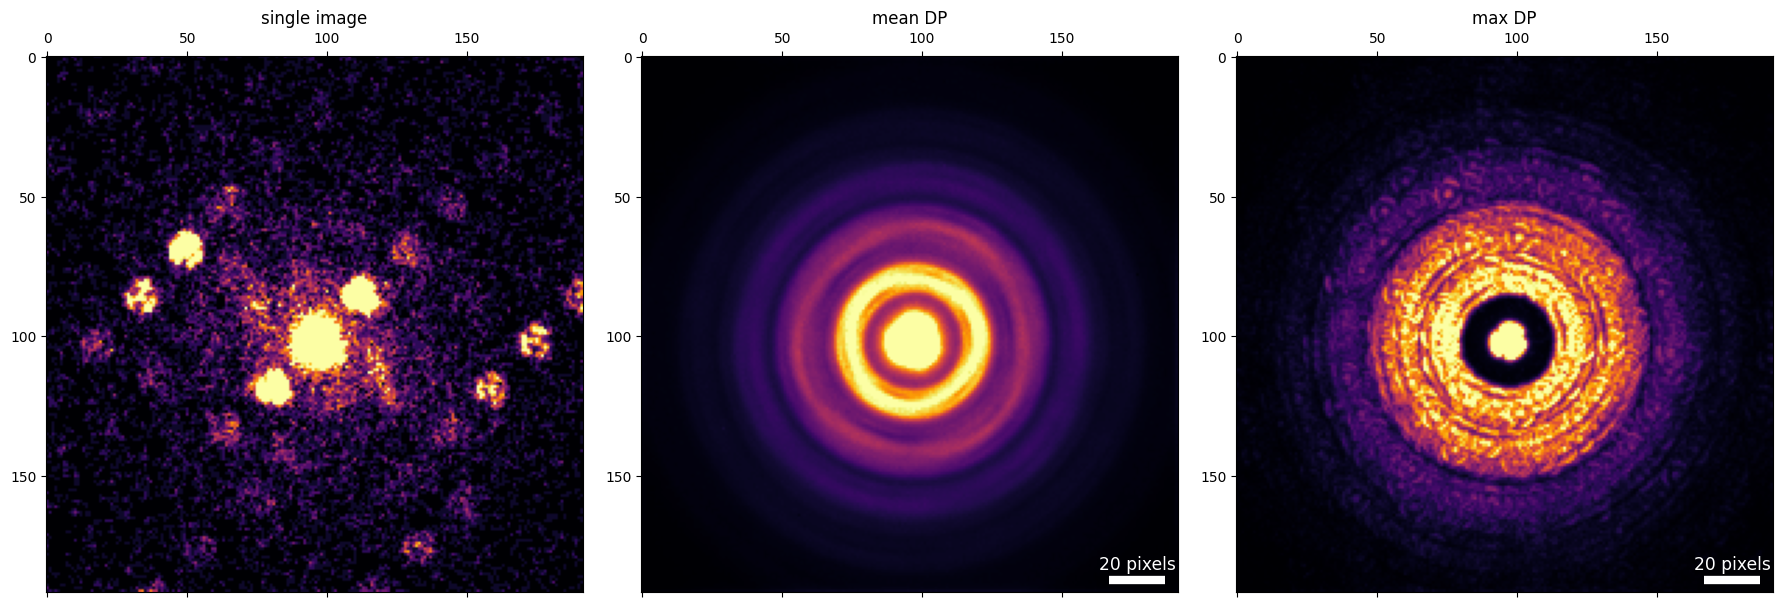

In [20]:
# show
p4.show(
    [
        datacube_masked.data[40,20],
        datacube_masked.get_dp_mean(),
        datacube_masked.get_dp_max(),
    ],
    cmap = 'inferno',
    title = ['single image','mean DP','max DP'],
    # power = 1,
)

Note that the center spot is shaped like a "rounded rectangle."  What you are seeing is the circular center spot, convolved with a rectangle shape corresponding to the STEM probe descan on the detector.  This is a shift of each diffraction pattern as a function of the STEM probe position. We will need to measure and correct these shifts.

In [21]:

p4.save(
    data = datacube_masked,
    filepath = path + f'{name}_masked.h5',)


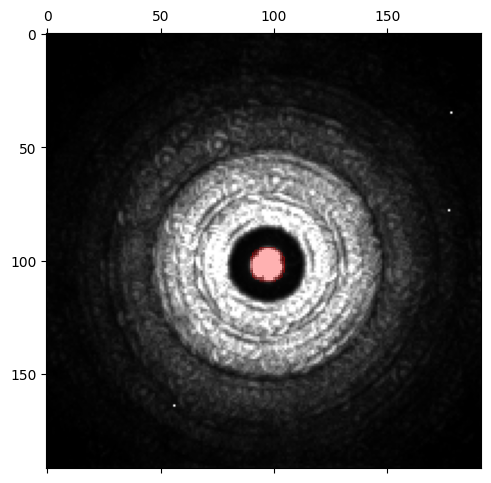

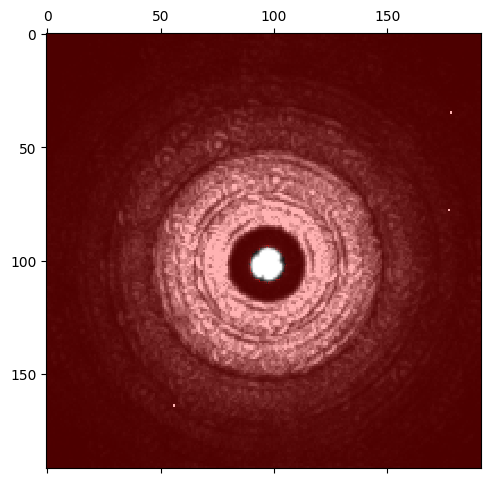

In [22]:
# Virtual imaging - position the detectors

# We'll generate a bright-field (BF) and an annular dark-field (ADF) virtual image
# for both the calibration and measurement datasets

# Set the center
center = (102,97)

# set the geometries
radius_bf = 8
geometry_bf = (center,radius_bf)
geometry_adf = (center,(radius_bf,10e3))

# display the detector positions
datacube.position_detector(
    data = dp_max,
    mode = 'circle',
    geometry = geometry_bf,
)
datacube.position_detector(
    data = dp_max,
    mode = 'annulus',
    geometry = geometry_adf,
)

100%|██████████| 16384/16384 [00:00<00:00, 64865.80it/s]


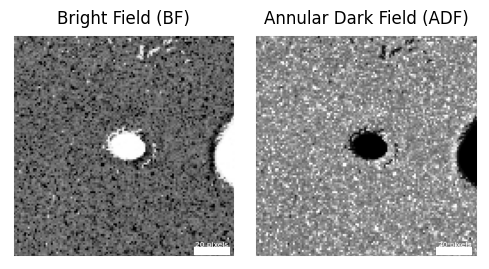

In [23]:
# Virtual imaging - compute the images

# compute
im_bf = datacube.get_virtual_image(
    mode = 'circle',
    geometry = geometry_bf,
    name = 'bright_field_cal',
)
im_adf = datacube.get_virtual_image(
    mode = 'annulus',
    geometry = geometry_adf,
    name = 'dark_field_cal',
)

# show
p4.show(
    [im_bf,im_adf],
    figsize=(16,2),
    bordercolor = 'w',
    cmap='gray',
    title=['Bright Field (BF)','Annular Dark Field (ADF)'],
    axsize = (2.5,4),
)

# Construct probe template

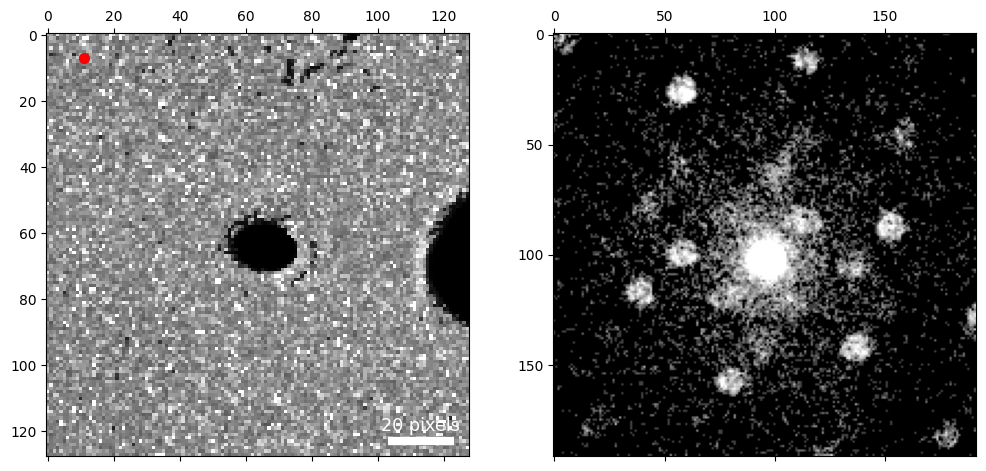

In [24]:
# Examine scan points for a vacuum probe

rx,ry = 7,11

p4.visualize.show_selected_dp(
    datacube,
    im_adf,
    rx,
    ry
)

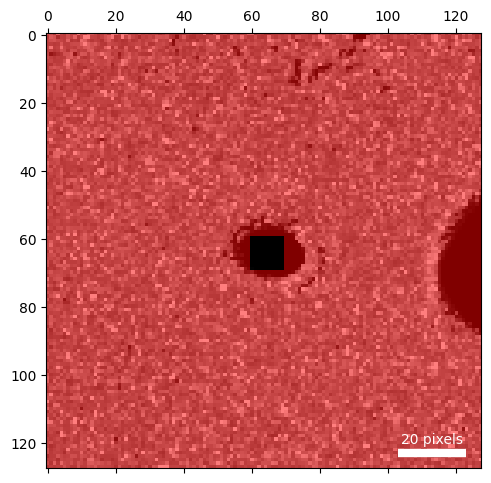

In [25]:
# Select a vacuum region

xlims = 60,70
ylims = 60,70

ROI = np.zeros(datacube.rshape, dtype=bool)
ROI[xlims[0]:xlims[1], ylims[0]:ylims[1]] = True

p4.show(
    im_adf,
    mask = ROI,
    mask_color = 'r',
    mask_alpha = 0.5
)

100%|██████████| 99/99 [00:00<00:00, 334.02it/s]


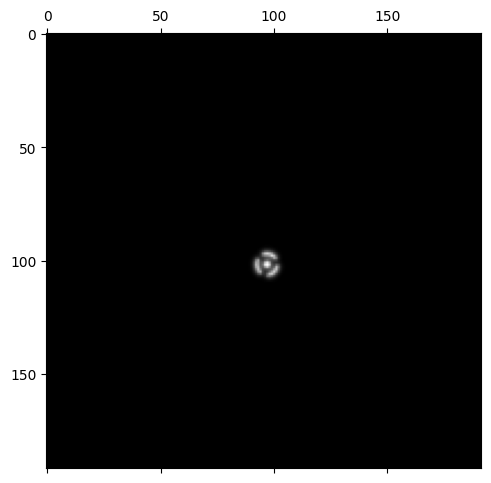

In [26]:
probe = datacube.get_vacuum_probe(
    ROI = ROI,
)

p4.show(
    probe.probe,
    vmax=1,
)

In [28]:
p4.save(
    data = probe.probe,
    filepath = path + f'{name}_probe.h5'
    )

In [27]:
probe.probe

array([[-9.81179066e-16,  2.04467441e-15,  1.75570150e-02, ...,
         7.57454436e-35,  3.78727218e-35,  3.78727218e-35],
       [ 1.60263522e-02,  2.63355225e-02,  1.85201057e-02, ...,
        -2.42792321e-48,  7.57454436e-35,  3.78727218e-35],
       [ 8.46685314e-03,  9.26005283e-03,  1.95175802e-02, ...,
         1.45450797e-47,  7.57454436e-35,  3.78727218e-35],
       ...,
       [ 3.78727218e-35,  6.29076974e-48,  4.82396157e-48, ...,
         2.63355225e-02,  2.40395283e-02,  7.29300929e-03],
       [-4.30794587e-48,  7.57454436e-35,  7.57454436e-35, ...,
         1.60263522e-02,  1.45860186e-02,  2.54306878e-02],
       [-5.66527152e-48,  7.57454436e-35,  3.78727218e-35, ...,
         7.29300929e-03,  6.35767194e-03, -4.73570462e-16]])

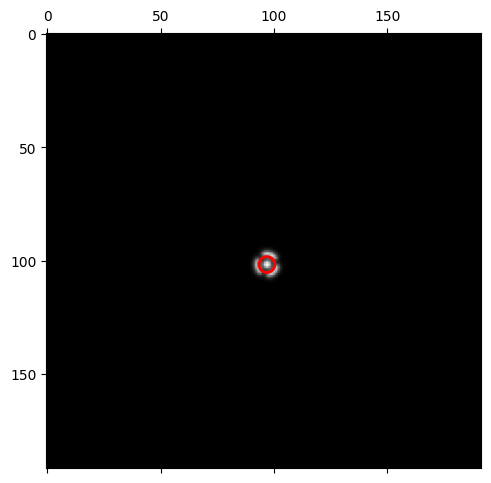

In [60]:
# Estimate the radius of the BF disk

probe_semiangle, probe_qx0, probe_qy0 = p4.process.calibration.get_probe_size(probe.probe)

p4.show(
    probe.probe,
    circle = {
        'center' : (probe_qx0,probe_qy0),
        'R' : probe_semiangle,
    },
    vmax = 1,
)

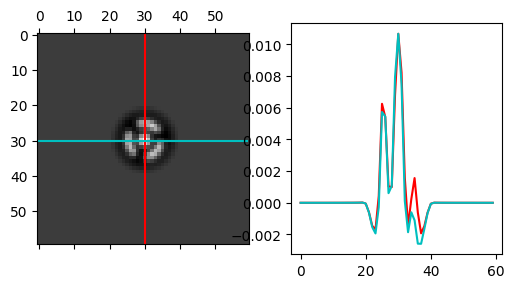

In [61]:
probe.get_kernel(
    mode = 'sigmoid',
    origin = (probe_qx0,probe_qy0),
    radii = (probe_semiangle * 1,
             probe_semiangle * 3,
    )
)

p4.visualize.show_kernel(
    probe.kernel,
    R = 30,
    L = 30,
    W = 1,
    figsize = (6,3),
)

# Find Bragg Peaks

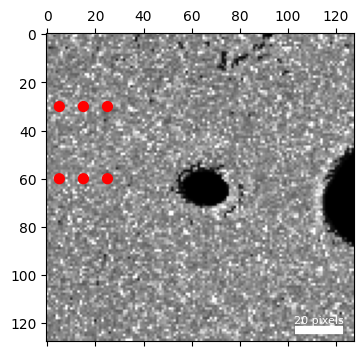

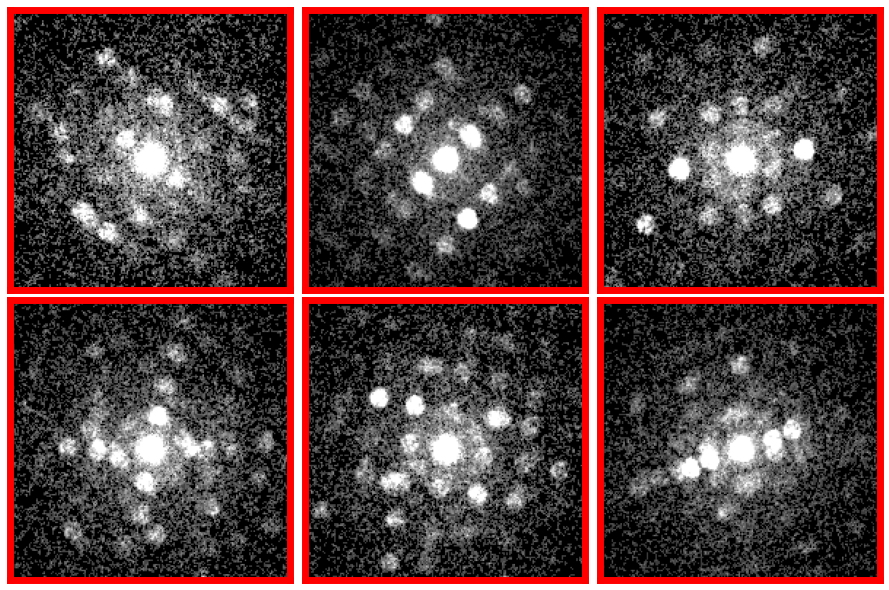

In [62]:
# Choose some diffraction patterns to use for hyperparameter tuning

rxs = 30,30,30,60,60,60
rys = 5,15,25,5,15,25

colors=['r','r','r','r','r','r']


p4.visualize.show_points(
    im_adf,
    x=rxs,
    y=rys,
    pointcolor=colors,
    figsize=(4,4)
)

p4.visualize.show_image_grid(
    get_ar = lambda i:datacube.data[rxs[i],rys[i],:,:],
    H=2,
    W=3,
    axsize=(3,3),
    power = 0.5,
    get_bordercolor = lambda i:colors[i],
)

In [64]:
bg_med = np.median(datacube.data)

def sub_bg(
    im,
    bg_fft=50,
    bg_real = 35,
):
    im_fft = np.fft.fft2(im)
    im_fft = np.maximum(np.abs(im_fft)-bg_fft,0.0) \
        * np.exp(1j * np.angle(im_fft))
    # im_out = np.maximum(np.real(np.fft.ifft2(im_fft)) - bg_real,0.0)
    im_out = np.real(np.fft.ifft2(im_fft)) - bg_real
    return im_out

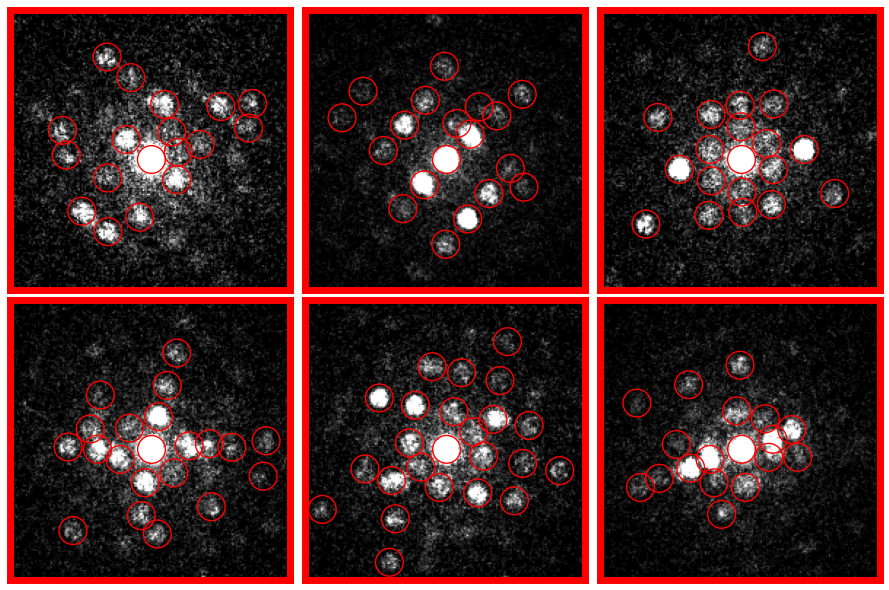

In [71]:
# Tune disk detection parameters

# disk detection parameters
detect_params = {
    'corrPower': 1,
    'sigma': 0,
    'edgeBoundary': 8,
    'minRelativeIntensity': 0.0001,
    'minAbsoluteIntensity': .5,
    'minPeakSpacing': 12,
    'subpixel': 'poly',
    'subpixel' : 'multicorr',
    'upsample_factor': 8,
    'maxNumPeaks': 200,
#     'CUDA': True,
    # 'filter_function': sub_bg,
}
# Note that "poly" subpixel fitting can be used to keep this tutoral fast, but "multicorr"
# is more accurate. For high precision strain mapping, subpixel="multicorr" is recommended.


# find the selected disks
disks_selected = datacube.find_Bragg_disks(
    data = (rxs, rys),
    template = probe.kernel,
    **detect_params,
)

# show
p4.visualize.show_image_grid(
    # get_ar = lambda i:datacube.data[rxs[i],rys[i],:,:],
    get_ar = lambda i:sub_bg(datacube.data[rxs[i],rys[i],:,:]),
    H=2,
    W=3,
    axsize=(3,3),
    # power = 0.5,
    get_bordercolor = lambda i:colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 400,
    # vmin = 0,
    # vmax = 0.,
)

In [72]:
# Find Bragg peaks in all probe positions.

braggpeaks = datacube.find_Bragg_disks(
    template = probe.kernel,
    **detect_params,
)

Finding Bragg Disks: 100%|██████████| 16.4k/16.4k [05:30<00:00, 49.6DP/s]


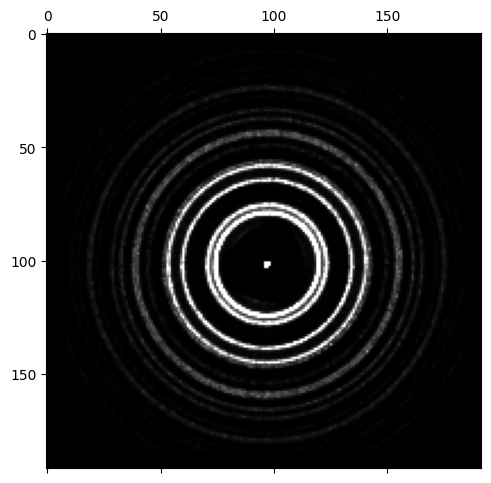

In [73]:
p4.show( braggpeaks.histogram() )

AttributeError: module 'py4DSTEM.process' has no attribute 'center_of_mass'

# Calibration

## Center coordinate system

(<Figure size 500x500 with 1 Axes>, <Axes: >)

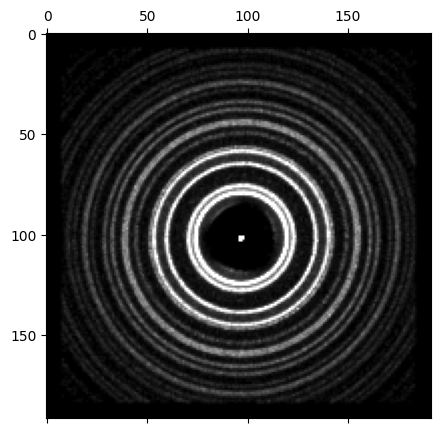

In [76]:
# Compute a Bragg vector map,
# i.e. a 2D histogram of the Bragg peak positions,
# weighted by their correlation intensities

bvm_raw = braggpeaks.histogram(mode = 'raw')

# Plot the BVM
bvm_vis_params = {
    'scaling':'power',
    'power':0.5,
}
p4.show(
    bvm_raw,
    **bvm_vis_params,
    returnfig = True
)

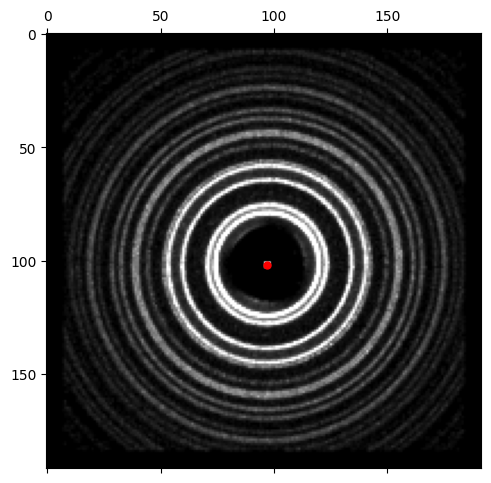

In [79]:
# Initial guess for the center position

center_guess = 102,97

p4.show(
    bvm_raw,
    points = {'x':center_guess[0],'y':center_guess[1]},
    **bvm_vis_params,
)

In [81]:
# Find the origin at each beam position

# measure the origin
origin_meas = braggpeaks.measure_origin( center_guess=center_guess )


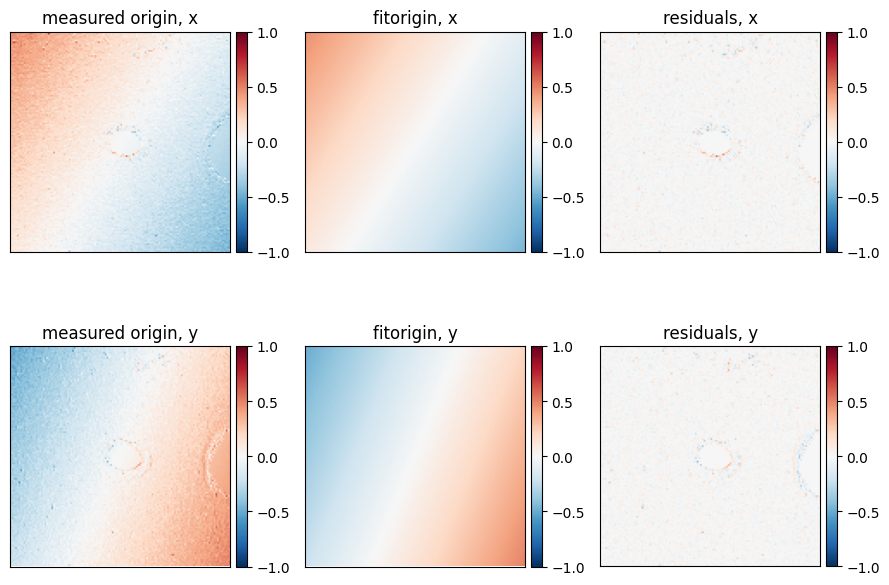

In [83]:

# fit a 2D plane
qx0_fit,qy0_fit,qx0_residuals,qy0_residuals = braggpeaks.fit_origin(
    ticks = False,
    plot_range = 1,
    axsize = (3,4),
)

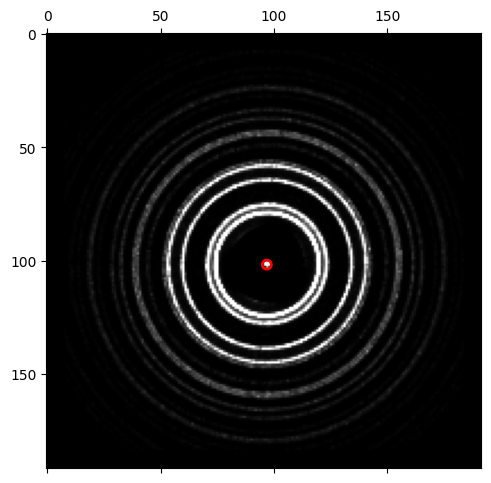

In [84]:
# Get the Bragg vector map after centering using our new origin measurements

# compute
bvm_centered = braggpeaks.histogram()

p4.show(
    bvm_centered,
    circle = {
        'center' : bvm_centered.origin,
        'R' : 2,
    },
    vmin=0,
    vmax=0.98
)

In [85]:
bvm_centered.origin

(101.70739540538561, 96.88694050191219)

In [90]:
?braggpeaks.calibrate

Signature: braggpeaks.calibrate()
Docstring: Autoupdate the calstate when relevant calibrations are set
File:      ~/miniconda3/envs/tem_colin/lib/python3.11/site-packages/py4DSTEM/braggvectors/braggvectors.py
Type:      method

In [86]:
import numpy as np
import matplotlib.pyplot as plt
# import py4DSTEM
from scipy.signal import find_peaks

# Assume 'braggpeaks' is your existing object from datacube.find_Bragg_disks()
# Assume 'detect_params' is the dictionary you used

## Step 1: Get center and calculate all peak radii
# First, get the summed diffraction pattern to find the global center

# CORRECTED LINE: call center_of_mass directly from the process module
center_x, center_y = bvm_centered.origin

print(f"Found pattern center at (x,y): ({center_x:.2f}, {center_y:.2f}) pixels")

# Get the coordinates of all detected disks
qx = braggpeaks.peak_props['qx']
qy = braggpeaks.peak_props['qy']

# Calculate the radius of every single peak from the center
radii_all_peaks = np.sqrt((qx - center_x)**2 + (qy - center_y)**2)


## Step 2: Create and fit the 1D radius histogram
# A histogram of the radii will show clear peaks for the rings
hist_counts, bin_edges = np.histogram(radii_all_peaks, bins=500)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Find the peaks in this histogram
peaks, _ = find_peaks(hist_counts, prominence=np.max(hist_counts)*0.05, distance=5)
ring_radii_pixels = bin_centers[peaks]

print(f"\nMeasured peak radii (pixels): {np.round(ring_radii_pixels, 2)}")

# Plot the histogram to verify
plt.figure(figsize=(10,6))
plt.plot(bin_centers, hist_counts, label='Histogram of Peak Radii')
plt.plot(ring_radii_pixels, hist_counts[peaks], "x", markersize=10, label='Detected Rings')
plt.title('Ring Positions from Bragg Peak Radii')
plt.xlabel('Radius (pixels)')
plt.ylabel('Counts')
plt.grid(True)
plt.legend()
plt.show()

## Step 3: Perform the final calibration (this part is unchanged)
# Gold (FCC) lattice parameter in Angstroms
a_Au = 4.078

# d-spacings for Gold
hkls = np.array([[1,1,1], [2,0,0], [2,2,0], [3,1,1], [2,2,2], [4,0,0]])
d_spacings_Au = a_Au / np.linalg.norm(hkls, axis=1)

# Fit the first N rings
num_rings_to_use = min(len(ring_radii_pixels), 4)
R_fit = ring_radii_pixels[:num_rings_to_use]
d_fit = d_spacings_Au[:num_rings_to_use]
inv_d_fit = 1 / d_fit

# Perform the linear fit
inv_d_reshaped = inv_d_fit[:, np.newaxis]
L_lambda, _, _, _ = np.linalg.lstsq(inv_d_reshaped, R_fit, rcond=None)
L_lambda = L_lambda[0]

print(f"\n--- Calibration Results ---")
print(f"Calibration Constant (Lλ): {L_lambda:.2f} pixels·Å")

# Plot the fit
plt.figure(figsize=(8, 6))
plt.plot(inv_d_fit, R_fit, 'o', label='Data Points')
plt.plot(inv_d_fit, L_lambda * inv_d_fit, 'r-', label=f'Linear Fit (Slope = {L_lambda:.2f})')
plt.title('Camera Constant Calibration')
plt.xlabel('Reciprocal d-spacing (1/Å)')
plt.ylabel('Measured Ring Radius (pixels)')
plt.grid(True)
plt.legend()
plt.show()

Found pattern center at (x,y): (101.71, 96.89) pixels


AttributeError: 'BraggVectors' object has no attribute 'peak_props'

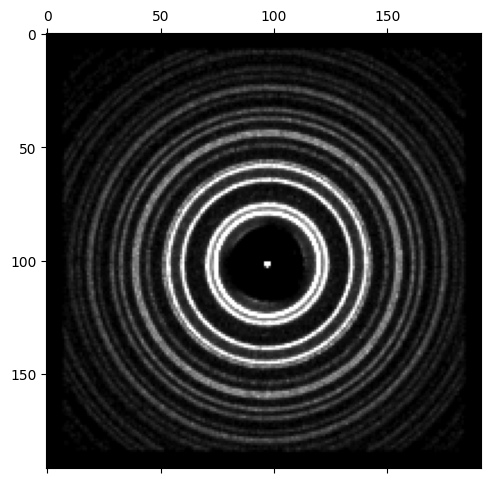

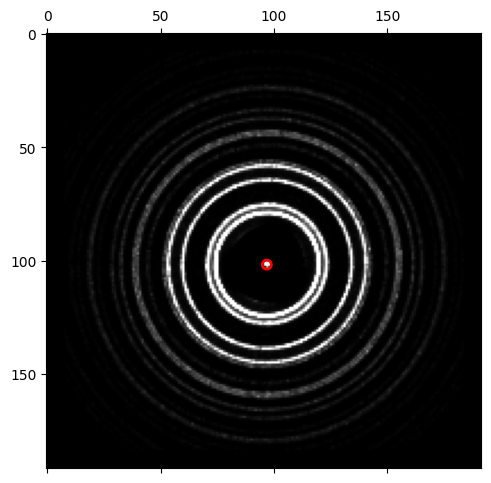

In [93]:
# Get the Bragg vector map after centering using our new origin measurements

# compute
bvm_centered_masked = braggpeaks.histogram()

# show
p4.show(
    bvm_centered_masked,
    **bvm_vis_params,
)
p4.show(
    bvm_centered_masked,
    vmin=0,
    circle = {
        'center' : bvm_centered_masked.origin,
        'R' : 2,
    },
)

## Ellipticity

In [ ]:
# # Select a region of thicker lacy carbon

# xlims = 75,86
# ylims = 35,43

# ROI_amorph = np.zeros(datacube.rshape, dtype=bool)
# ROI_amorph[xlims[0]:xlims[1], ylims[0]:ylims[1]] = True

# show(
#     im_adf,
#     mask = ROI_amorph,
#     mask_color = 'r',
#     mask_alpha = 0.5
# )

In [ ]:
# im_SAED_amorph = datacube.get_virtual_diffraction(
#     'mean',
#     mask = ROI_amorph,
#     shift_center = True
# )

# show(
#     im_SAED_amorph,
#     intensity_range = 'absolute',
#     vmin = 4e1,
#     vmax = 8e3,
#     scaling = 'log'
# )

In [ ]:
# # Select fit radii

# q_range = (16,36)

# p4.show(
#     im_SAED_amorph.data,
#     intensity_range = 'absolute',
#     vmin = 4e1,
#     vmax = 8e3,
#     scaling = 'log',
#     annulus={
#         'center':im_SAED_amorph.calibration.get_origin_mean(),
#         'radii': q_range,'fill':True,'color':'r','alpha':0.3}
# )

In [ ]:
# # Fit the amorphous halo

# p_ellipse,p_dsg = p4.process.calibration.fit_ellipse_amorphous_ring(
#     data = im_SAED_amorph.data,
#     center = im_SAED_amorph.calibration.get_origin_mean(),
#     fitradii = q_range
# )

# # Show the fit
# p4.visualize.show_amorphous_ring_fit(
#     im_SAED_amorph.data,
#     fitradii = q_range,
#     p_dsg = p_dsg,
# )

In [ ]:
# print(p_ellipse)

In [ ]:
# Set the ellipse calibration

p_ellipse = (center_guess[0],center_guess[1],1,1,0)

braggpeaks.calibration.set_p_ellipse(p_ellipse)
braggpeaks.setcal()

In [ ]:
braggpeaks.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:       1
             R_pixel_size:       49.5
             Q_pixel_units:      pixels
             R_pixel_units:      nm
             QR_flip:            False
             _root_treepath:     
             qx0_meas:           2D-array
             qy0_meas:           2D-array
             origin_meas_mask:   2D-array
             qx0:                2D-array
             qx0_mean:           69.88582760320448
             qx0_shift:          2D-array
             qy0:                2D-array
             qy0_mean:           64.42019902194546
             qy0_shift:          2D-array
             a:                  1
             b:                  1
             theta:              0
)

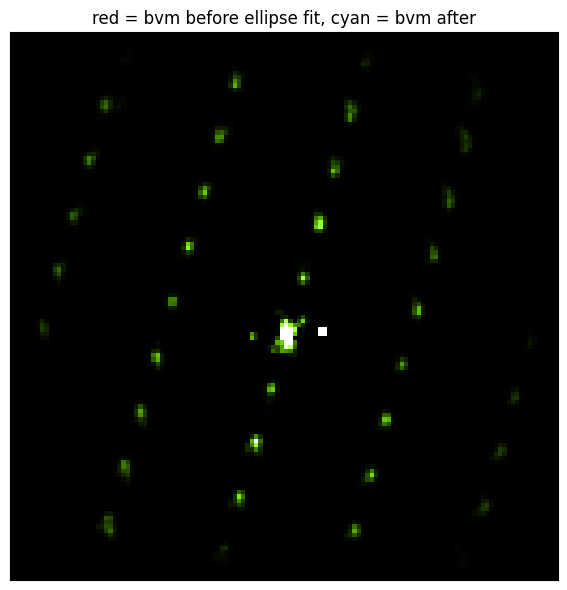

In [ ]:
# compute
bvm_ellipse = braggpeaks.histogram( mode='cal' )

# show
p4.show(
    [bvm_centered, bvm_ellipse],
    vmax=0.999,
    combine_images = True,
    title = "red = bvm before ellipse fit, cyan = bvm after",
    figsize = (6,6),
    ticks = False,
)

In [ ]:
# # Get a new corrected BVM

# # compute
# bvm_ellipse = braggpeaks.histogram( mode='cal' )


# # show
# show(
#     # [bvm_centered_masked, bvm_ellipse],
#     [bvm_centered, bvm_ellipse],
#     vmax=0.99,
#     title = ["bvm before ellipse fit", "bvm after ellipse fit"],
#     axsize = (4,4),
# )

## Rotation

Measure Q/R rotation with pseudo-dpc with only the center beam

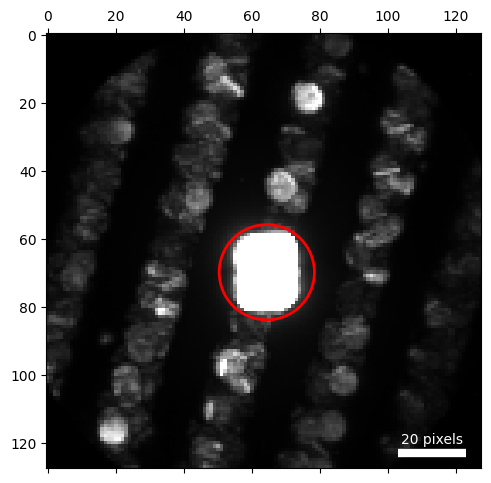

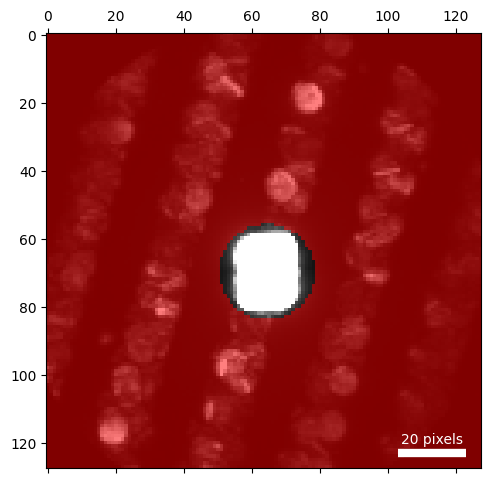

In [ ]:
# make a mask

mask_radius = 14

qyy,qxx = np.meshgrid(
    np.arange(datacube.qshape[1]),
    np.arange(datacube.qshape[0]),
)
origin = braggpeaks.calibration.get_origin_mean()
qq = np.hypot(qxx-origin[0],qyy-origin[1])
mask_pseudoDPC = qq<mask_radius

p4.show(
    dp_max,
    vmax = 0.975,
    circle = {
        'center' : braggpeaks.calibration.get_origin_mean(),
        'R' : mask_radius
    }
)
p4.show(
    dp_max,
    vmax = 0.975,
    mask = mask_pseudoDPC,
    mask_color = 'r',
    mask_alpha = 0.5
)

Iterative reconstruction will not be quantitative unless you specify appropriate reciprocal-space calibrations
Calculating center of mass: 100%|██████████| 4050/4050 [00:00<00:00, 8987.20probe position/s]
Best fit rotation = -71 degrees.
Diffraction intensities should be transposed.


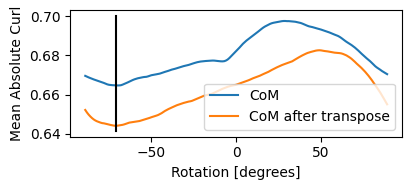

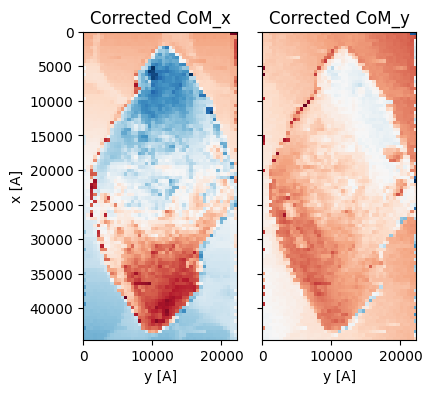

In [ ]:
# perform DPC preprocessing

dpc = p4.process.phase.DPC(
    datacube = datacube,
).preprocess(
    dp_mask = mask_pseudoDPC,
)

In [ ]:
# The rotation was measured at roughly -71 degrees and is input below manually.
# Note the sign change!  Unfortunately, the DPC module and strain module use
# opposite rotation conventions.

# braggpeaks.calibration.set_QR_rotation_degrees(71)
braggpeaks.calibration.set_QR_rotation_degrees(73)
braggpeaks.calibration.set_QR_flip(True)
# braggpeaks.setcal()

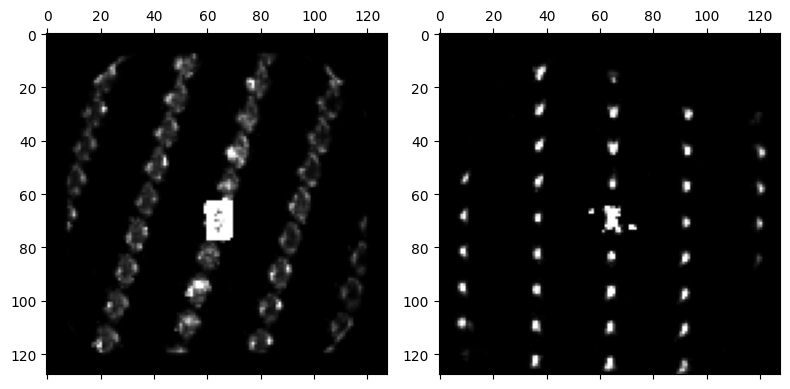

In [ ]:
# Update BVM

# compute
bvm = braggpeaks.histogram( mode='cal' )

# show
p4.show([bvm_raw, bvm],vmax=0.99, axsize=(4,4))

# Strain

In [ ]:
strainmap = p4.StrainMap( braggvectors=braggpeaks )

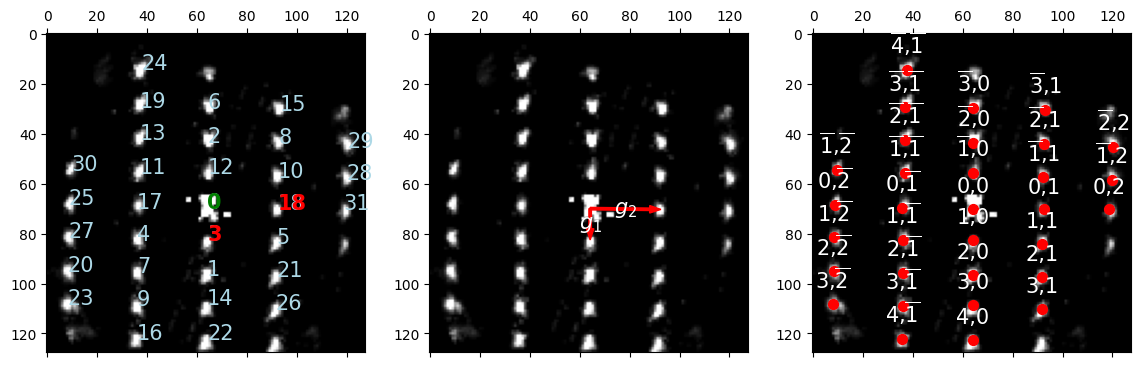

In [ ]:
strainmap.choose_basis_vectors(
    minSpacing=10,
    minAbsoluteIntensity=5000,
    maxNumPeaks=100,
    edgeBoundary=5,
    vis_params = bvm_vis_params,
    # index_g1 = 11,
    # index_g2 = 9,
)

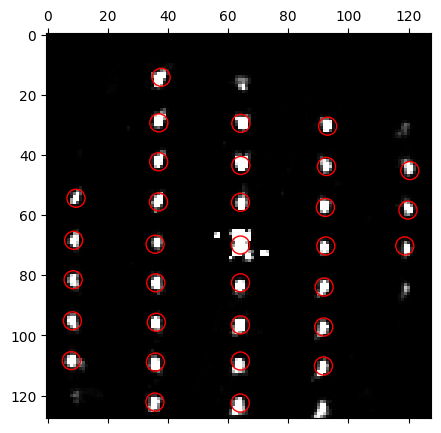

Indexing Bragg scattering: 100%|██████████| 4.05k/4.05k [00:04<00:00, 996DP/s]  
Fitting lattice vectors: 100%|██████████| 4.05k/4.05k [00:01<00:00, 2.10kDP/s]


In [ ]:
strainmap.fit_basis_vectors(
    max_peak_spacing = 3,
)

In [ ]:
# strainmap.get_strain?

Calculating strain: 100%|██████████| 4.05k/4.05k [00:02<00:00, 1.62kDP/s]


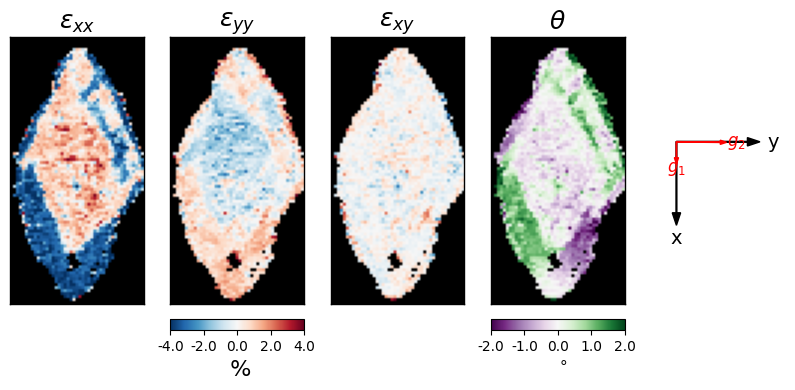

In [ ]:
# strain map

strainmap.get_strain(
    coordinate_rotation = 0,
    layout = "horizontal",
    vrange = [-4.0, 4.0],
    vrange_theta = [-2.0, 2.0],
    # mask_color = "blue"
)

In [ ]:
# strainmap.show_strain?

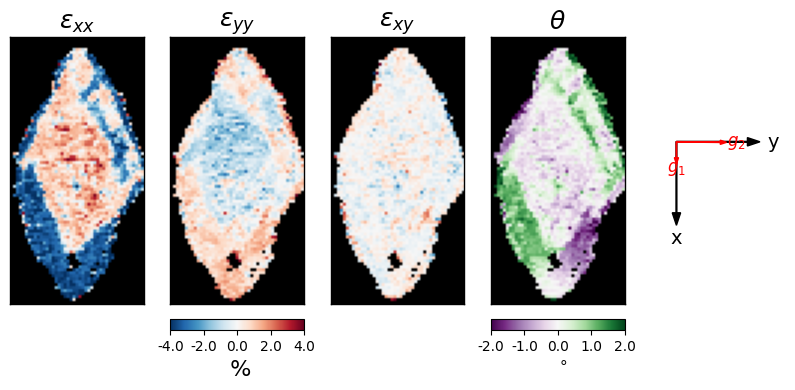

In [ ]:
strainmap.show_strain(
    layout = "horizontal",
    vrange = [-4.0, 4.0],
    vrange_theta = [-2.0, 2.0],
    show_gvects = True,
)

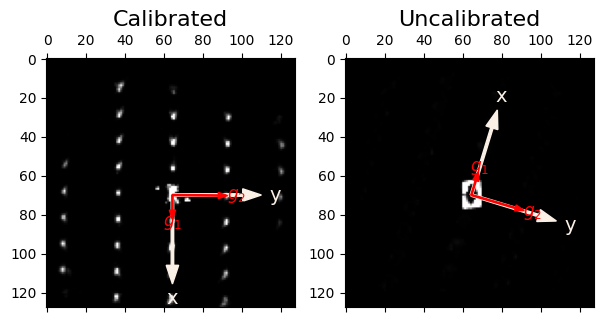

In [ ]:
strainmap.show_reference_directions(
    visp_cal={
        'scaling' : 'none',
        'vmax' : 0.995
    },
    visp_uncal={
        'scaling' : 'none',
        'vmax' : 0.995
    },
    camera_length = 1.4,
)

# Strain using reference $g_1$ and $g_2$ from an ROI

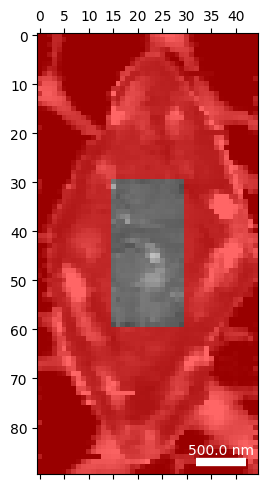

In [ ]:
# Set reference region

ROI = np.zeros(braggpeaks.Rshape, dtype=bool)
ROI[30:60, 15:30] = True

p4.show(
    im_adf,
    mask = ROI,
    mask_color='r',
    mask_alpha=0.4
)

Calculating strain: 100%|██████████| 4.05k/4.05k [00:03<00:00, 1.08kDP/s]


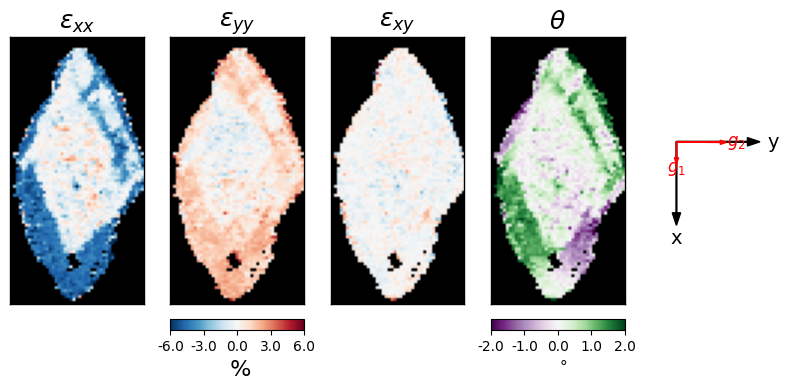

In [ ]:
# strain from a region

strainmap.get_strain(
    gvects = ROI,
   coordinate_rotation = 0,
    # coordinate_rotation = -55,
#    coordinate_rotation = -100,
    layout = "horizontal",
    vrange = [-6.0, 6.0],
    vrange_theta = [-2.0, 2.0],
)

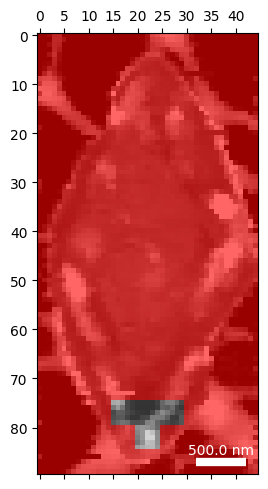

In [ ]:
# Set reference region

ROI = np.zeros(braggpeaks.Rshape, dtype=bool)
ROI[75:80, 15:30] = True
ROI[80:85, 20:25] = True


p4.show(
    im_adf,
    mask = ROI,
    mask_color='r',
    mask_alpha=0.4
)

Calculating strain: 100%|██████████| 4.05k/4.05k [00:01<00:00, 3.15kDP/s]


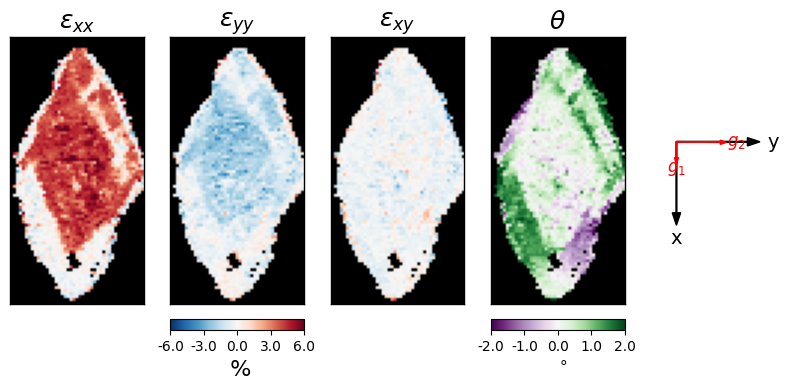

In [ ]:
# strain from a region

strainmap.get_strain(
    gvects = ROI,
   coordinate_rotation = 0,
    # coordinate_rotation = -55,
#    coordinate_rotation = -100,
    layout = "horizontal",
    vrange = [-6.0, 6.0],
    vrange_theta = [-2.0, 2.0],
)

# Strain using a manually specified reference $g_1$ and $g_2$

In [ ]:
# g1_ref, g2_ref = strainmap.get_reference_g1g2( ROI )

# strainmap.get_strain(
#     gvects = (g1_ref,g2_ref),
#     coordinate_rotation = -55,
#     layout = "horizontal",
#     vrange = [-6.0, 6.0],
#     vrange_theta = [-2.0, 2.0],
# )